# Calculate OvO acc

In [4]:
import json, os

def evaluate_ovobench_results(results: list):
    task_to_counts = {}
    for result in results:
        task = result['task']
        if task not in task_to_counts:
            task_to_counts[task] = {'correct': 0, 'total': 0}
        task_to_counts[task]['total'] += 1
        if result['response'][:len(result['answer'])] == result['answer']:
            task_to_counts[task]['correct'] += 1
    rt_accs, bt_accs, fr_accs = [], [], []
    for task, counts in task_to_counts.items():
        print(f'{task}: {counts["correct"]}/{counts["total"]}={counts["correct"]/counts["total"]}')
        if task in ['OCR', 'ACR', 'ATR', 'STU', 'FPD', 'OJR']:
            rt_accs.append(counts['correct']/counts['total'])
        elif task in ['EPM', 'ASI', 'HLD']:
            bt_accs.append(counts['correct']/counts['total'])
        else:
            fr_accs.append(counts['correct']/counts['total'])
    if rt_accs:
        print(f'Real-Time Visual Perception avg.: {sum(rt_accs)}/{len(rt_accs)}={sum(rt_accs)/len(rt_accs)}')
    if bt_accs:
        print(f'Backward Tracing avg.: {sum(bt_accs)}/{len(bt_accs)}={sum(bt_accs)/len(bt_accs)}')
    if fr_accs:
        print(f'Forward Tracing avg.: {sum(fr_accs)}/{len(fr_accs)}={sum(fr_accs)/len(fr_accs)}')

results = json.load(open('/2022233235/videollm-online/livecc/evaluation/ovobench/results/LiveCC-7B-Instruct.json'))

eval_results = evaluate_ovobench_results(results)


EPM: 173/297=0.5824915824915825
HLD: 172/186=0.9247311827956989
ASI: 78/148=0.527027027027027
STU: 76/178=0.42696629213483145
OJR: 109/184=0.592391304347826
ATR: 75/116=0.646551724137931
FPD: 68/101=0.6732673267326733
ACR: 47/109=0.43119266055045874
OCR: 106/149=0.7114093959731543
CRR: 130/240=0.5416666666666666
SSR: 412/629=0.6550079491255962
REC: 241/698=0.3452722063037249
Real-Time Visual Perception avg.: 3.481778703876875/6=0.5802964506461458
Backward Tracing avg.: 2.0342497923143084/3=0.6780832641047695
Forward Tracing avg.: 1.5419468220959875/3=0.5139822740319958


In [12]:
results = json.load(open('/2022233235/videollm-online/livecc/evaluation/ovobench/results/LiveCC-7B-Instruct.json'))
json.dump(results, open('/2022233235/videollm-online/livecc/evaluation/ovobench/results/LiveCC-7B-Instruct-formatted.json', 'w'), indent=4)

In [ ]:
results = json.load(open('/2022233235/videollm-online/livecc/evaluation/ovobench/results/LiveCC-7B-Instruct.json'))

# vis OvObench

In [4]:
import json, os, torch, functools, tqdm, random, sys
import numpy as np
import decord
from torch.utils.data import Dataset
from transformers import Trainer, TrainingArguments, logging, Qwen2VLForConditionalGeneration, AutoProcessor

from livecc_utils import _read_video_decord_plus, _spatial_resize_video
from qwen_vl_utils.vision_process import process_vision_info, smart_nframes, FPS

logger = logging.get_logger(__name__)

def _read_may1fps_video_decord(ele: dict):
    """read video using decord.VideoReader. can handle more cases compared to _read_video_decord.

    Args:
        ele (dict): a dict contains the configuration of video.
        support keys:
            - video: the path of video. support "file://", "http://", "https://" and local path.
            - video_start: the start time of video.
            - video_end: the end time of video.
    Returns:
        torch.Tensor: the video tensor with shape (T, C, H, W).
        sample_fps
        clip_pts if return_pts=True
    """
    video_path = ele["video"]
    if os.path.exists(video_path):
        vr = decord.VideoReader(video_path, num_threads=2)
    elif ele['remote_loader'] is not None:
        vr = decord.VideoReader(ele['remote_loader'](video_path), num_threads=2)
    else:
        raise ValueError(f'video_path {video_path} not found')
    video_start = ele.get('video_start', None)
    video_end = ele.get('video_end', None)
    video_fps = vr.get_avg_fps()
    clip_idxs, clip_pts = None, None
    if video_start is not None or video_end is not None:
        vr.get_frame_timestamp(0)
        video_pts = vr._frame_pts[:,1]
        video_start = video_pts[0] if not video_start else video_start
        video_end = video_pts[-1] if not video_end else video_end
        video_start = min(max(video_pts[0], video_start), video_pts[-1])
        video_end = min(max(video_pts[0], video_end), video_pts[-1])
        video_end = max(video_start + 1, video_end)
        clip_idxs = ((video_start <= video_pts) & (video_pts <= video_end)).nonzero()[0]
        total_frames = len(clip_idxs)
    else:
        total_frames = len(vr)
    total_frames_for_smart_nframes = total_frames
    video_fps_for_smart_nframes = video_fps
    if total_frames < 2:
        total_frames_for_smart_nframes = 2
    if video_fps < FPS: # FPS=2
        total_frames_for_smart_nframes = int(total_frames * FPS / video_fps)
        video_fps_for_smart_nframes = FPS
    nframes = smart_nframes(ele, total_frames=total_frames_for_smart_nframes, video_fps=video_fps_for_smart_nframes) 
    nframes_idxs = np.linspace(0, total_frames - 1, nframes).round().astype(int)
    clip_idxs = nframes_idxs if clip_idxs is None else clip_idxs[nframes_idxs]
    # clip = torch.from_numpy(vr.get_batch(clip_idxs).asnumpy()).permute(0, 3, 1, 2)  # Convert to TCHW format
    frame = vr.get_batch([0]).asnumpy()
    clip = torch.zeros(nframes, 3, frame.shape[1], frame.shape[2])
    sample_fps = len(clip_idxs) / max(total_frames, 1e-6) * video_fps
    return clip, sample_fps


origin_video_len = []
load_video_len = []
origin_video_pixels = []
load_video_pixels = []

class OvoBenchMCQDataset(Dataset):
    def __init__(self, remote_loader, path, question_prefix, question_postfix, answer_prefix, sample: int = None):
        lines = open(path).readlines()
        if sample is not None:
            random.seed(42)
            lines = random.sample(lines, sample)
        self.datums = [json.loads(line) for line in tqdm.tqdm(lines, desc='load datums')]
        if isinstance(self.datums[0], str):
            self.datums = [json.loads(datum) for datum in tqdm.tqdm(self.datums, desc='load datumsx2')]
        # self.datums = [datum for datum in self.datums if datum['task'] not in ['REC', 'SSR', 'CRR']]
        self.src_video_dir = os.path.dirname("/2022233235/.cache/huggingface/hub/datasets--JoeLeelyf--OVO-Bench/snapshots/fec29e3385747b5642d995370143ba92d2819bd2/src_videos/")
        self.question_prefix = question_prefix
        self.question_postfix = question_postfix
        self.answer_prefix = answer_prefix
        self.remote_loader = remote_loader
        
    def __len__(self):
        return len(self.datums)

    def __getitem__(self, i):
        datum = self.datums[i]
        conversation = [{"role": "user", "content": []}]
        video_inputs = None
        if datum['task'] in ['REC', 'SSR', 'CRR']: # 'REC', 'SSR', 'CRR' have already been chunked
            query = datum['question']
            video, _ = _read_may1fps_video_decord({'video': os.path.join(self.src_video_dir, datum['video']),'video_end': datum['video_end'],'remote_loader': self.remote_loader})
        else:
            query = self.question_prefix + datum['question'] + '\n' + '\n'.join(datum['options']) + self.question_postfix
            video, _ = _read_may1fps_video_decord({'video': os.path.join(self.src_video_dir, datum['video']), 'video_end': datum['video_end'], 'remote_loader': self.remote_loader})
        
        # HACK: add hook
        origin_video_len.append(datum['video_end'] * 2)
        origin_video_pixels.append(video.shape[1] * video.shape[2])
        load_video_len.append(video.shape[0])
        
        video = _spatial_resize_video(video)
        
        load_video_pixels.append(video.shape[1] * video.shape[2])
        
        conversation[0]['content'].append({"type": "video", "video": video})
        video_inputs = [video]
        conversation[0]['content'].append({"type": "text", "text": query})
        if video_inputs is None:
            for _ in range(10):
                try:
                    _, video_inputs = process_vision_info(conversation)
                    break
                except:
                    print(f"{_}-th process_vision_info failed. retry...")
        return conversation, video_inputs[0]

    def data_collator(self, batch, processor):
        conversations, video_inputs = zip(*batch)
        texts = processor.apply_chat_template(conversations, tokenize=False, add_generation_prompt=True)
        texts = [text + self.answer_prefix for text in texts]
        inputs = processor(
            text=texts,
            images=None,
            videos=video_inputs,
            padding=True,
            return_tensors="pt",
        )
        return inputs

benchmark_path = '/2022233235/videollm-online/livecc/ovo-bench-formatted.jsonl' 
options = ['No', 'Yes', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E']
use_liger_kernel=True
answer_prefix = 'The answer is:\n', 
abcd_previous_str = '\n',
remote_loader=None

ovo_dataset = OvoBenchMCQDataset(remote_loader=None, path=benchmark_path, question_prefix='', question_postfix='\nPlease select the correct answer.', answer_prefix='Answer:')

from tqdm import tqdm
for i in tqdm(range(len(ovo_dataset))):
    conversation, video_inputs = ovo_dataset[i]

import torch
dataset_frame_info = {
    'origin_video_len': origin_video_len,
    'load_video_len': load_video_len,
    'origin_video_pixels': origin_video_pixels,
    'load_video_pixels': load_video_pixels,
}
torch.save(dataset_frame_info, '/2022233235/videollm-online/livecc/evaluation/ovobench/results/dataset_frame_info.pt')



load datums:   0%|          | 0/3035 [00:00<?, ?it/s]

100%|██████████| 3035/3035 [37:21<00:00,  1.35it/s]  


/tmp/ipykernel_94003/1706794736.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  dataset_frame_info = torch.load('/2022233235/videollm-online/livecc/evaluation/ovobench/r

1348


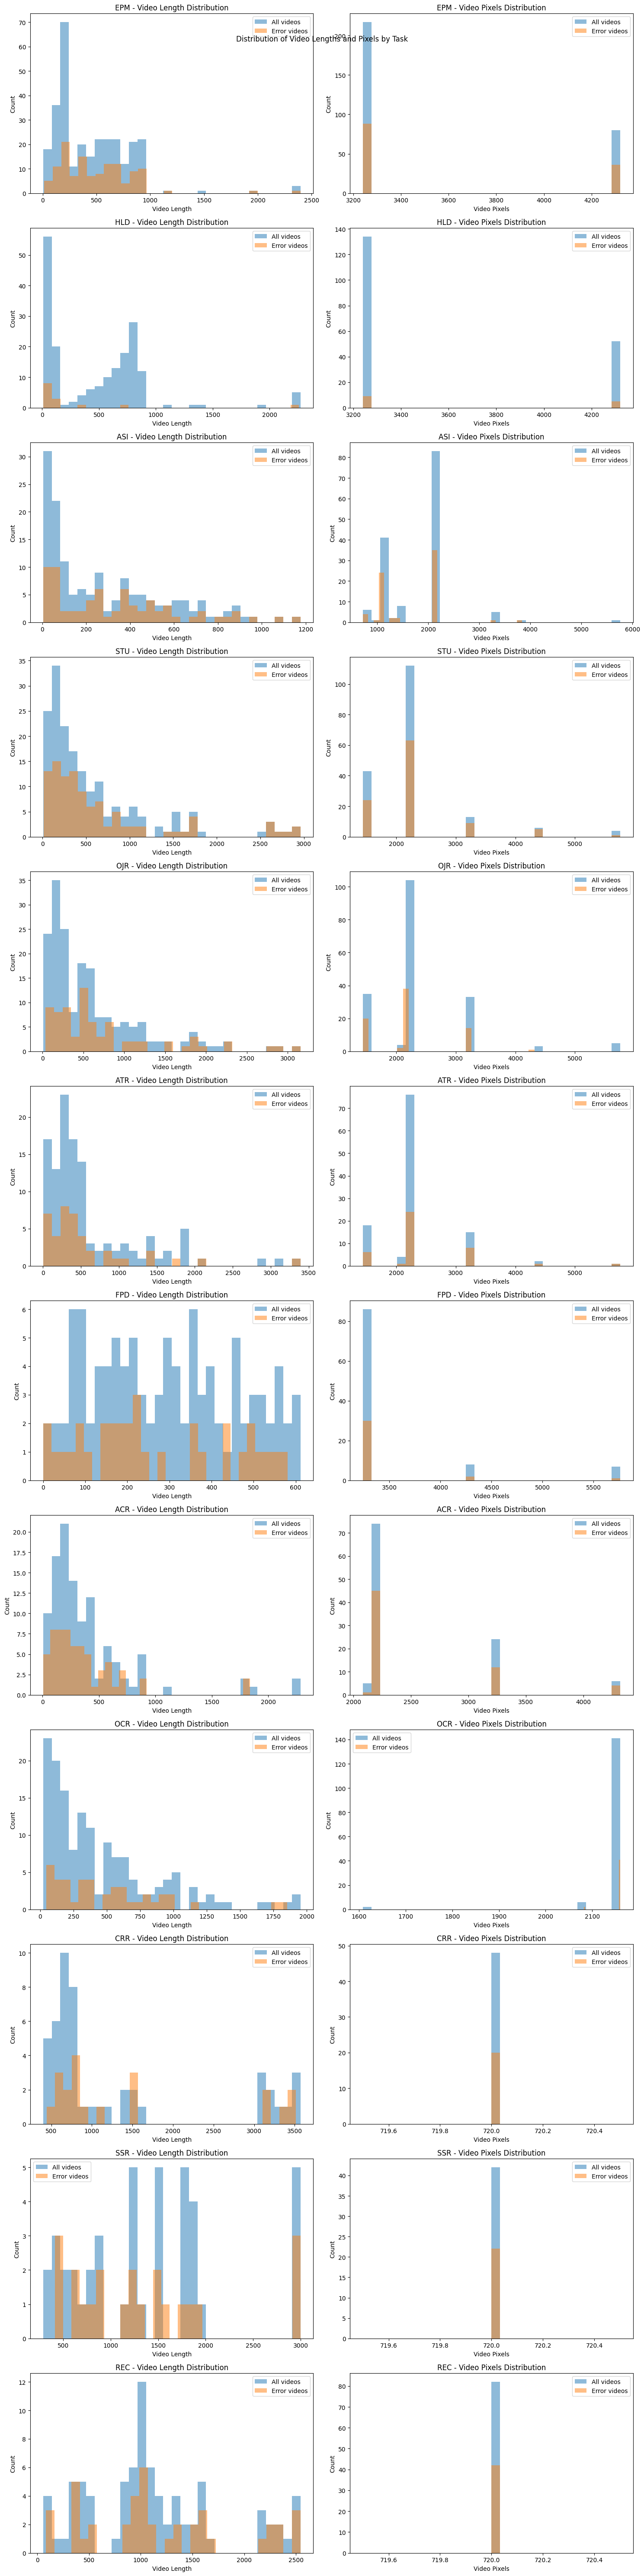

In [7]:
import torch
dataset_frame_info = torch.load('/2022233235/videollm-online/livecc/evaluation/ovobench/results/dataset_frame_info.pt')
origin_video_len = dataset_frame_info['origin_video_len']
origin_video_pixels = dataset_frame_info['origin_video_pixels']
load_video_len = dataset_frame_info['load_video_len']
load_video_pixels = dataset_frame_info['load_video_pixels']

import matplotlib.pyplot as plt
import numpy as np

import json

dums = json.load(open("/2022233235/videollm-online/livecc/ovo_bench_new.json"))
task2id = {}
for i, datum in enumerate(dums):
    if datum['task'] not in task2id:
        task2id[datum['task']] = []
    task2id[datum['task']].append(i)



results = json.load(open('evaluation/ovobench/results/LiveCC-7B-Instruct.json'))
error_ids = []
for i, result in enumerate(results):
    if result['response'][:len(result['answer'])] != result['answer']:
        error_ids.append(i)

print(len(error_ids))

# Plot histograms for video length and pixels by task
tasks = list(task2id.keys())
fig, axes = plt.subplots(len(tasks), 2, figsize=(15, 5*len(tasks)))
fig.suptitle('Distribution of Video Lengths and Pixels by Task')

for i, task in enumerate(tasks):
    task_ids = task2id[task]
    task_error_ids = [idx for idx in error_ids if idx in task_ids]
    
    # Plot video length distribution
    axes[i,0].hist([origin_video_len[j] for j in task_ids], bins=30, alpha=0.5, label='All videos')
    axes[i,0].hist([origin_video_len[j] for j in task_error_ids], bins=30, alpha=0.5, label='Error videos')
    axes[i,0].set_xlabel('Video Length')
    axes[i,0].set_ylabel('Count')
    axes[i,0].set_title(f'{task} - Video Length Distribution')
    axes[i,0].legend()
    
    # Plot video pixels distribution
    axes[i,1].hist([origin_video_pixels[j] for j in task_ids], bins=30, alpha=0.5, label='All videos')
    axes[i,1].hist([origin_video_pixels[j] for j in task_error_ids], bins=30, alpha=0.5, label='Error videos')
    axes[i,1].set_xlabel('Video Pixels')
    axes[i,1].set_ylabel('Count')
    axes[i,1].set_title(f'{task} - Video Pixels Distribution')
    axes[i,1].legend()

plt.tight_layout()
plt.show()


1348


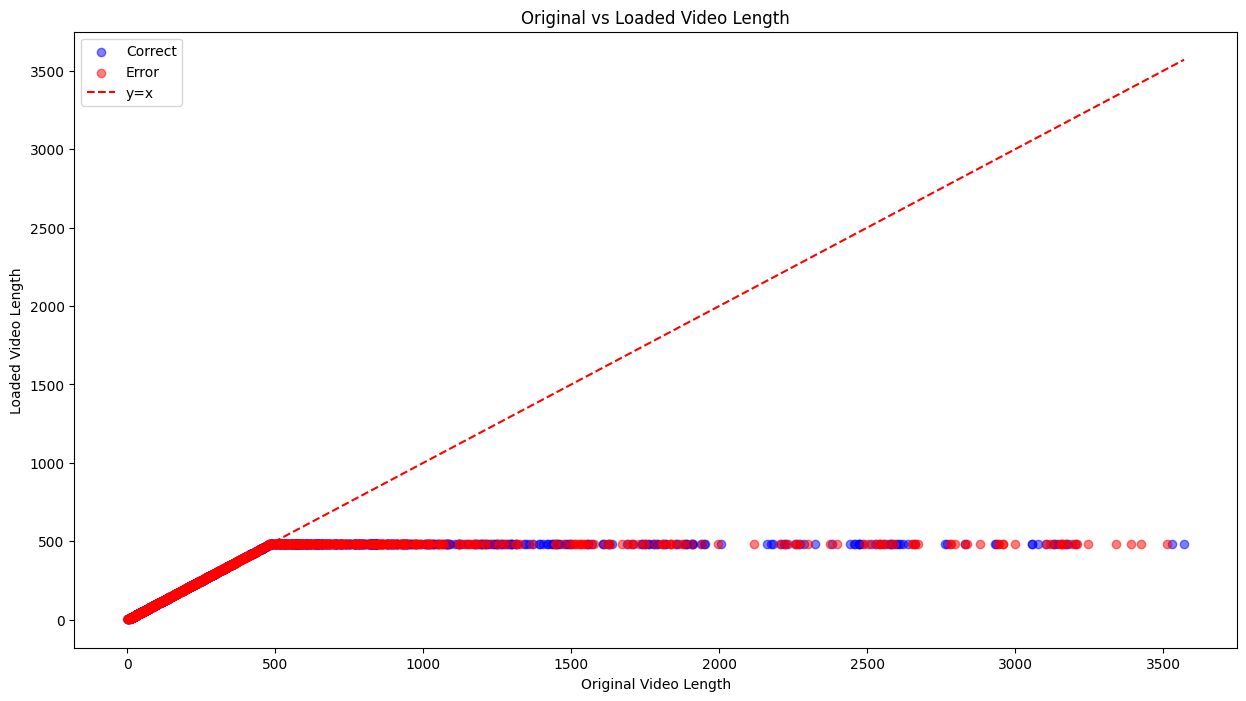

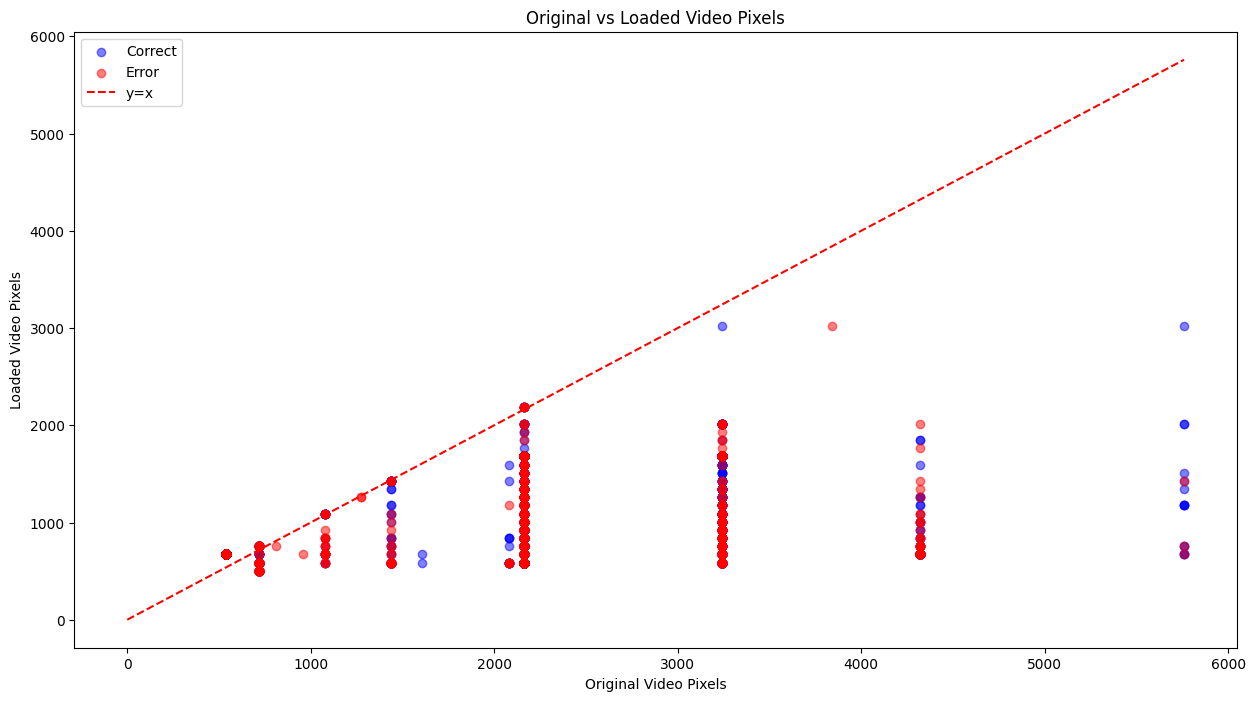

In [5]:

import matplotlib.pyplot as plt
import numpy as np

import json

results = json.load(open('evaluation/ovobench/results/LiveCC-7B-Instruct.json'))
error_ids = []
for i, result in enumerate(results):
    if result['response'][:len(result['answer'])] != result['answer']:
        error_ids.append(i)

print(len(error_ids))

# Plot video length comparison
plt.figure(figsize=(15, 8))
# Plot correct predictions in blue
correct_mask = ~np.isin(np.arange(len(origin_video_len)), error_ids)
plt.scatter(np.array(origin_video_len)[correct_mask], np.array(load_video_len)[correct_mask], alpha=0.5, color='blue', label='Correct')
# Plot errors in red
plt.scatter(np.array(origin_video_len)[error_ids], np.array(load_video_len)[error_ids], alpha=0.5, color='red', label='Error')
plt.plot([0, max(origin_video_len)], [0, max(origin_video_len)], 'r--', label='y=x')
plt.xlabel('Original Video Length')
plt.ylabel('Loaded Video Length')
plt.title('Original vs Loaded Video Length')
plt.legend()
plt.show()

# Plot video pixels comparison
plt.figure(figsize=(15, 8))
# Plot correct predictions in blue
plt.scatter(np.array(origin_video_pixels)[correct_mask], np.array(load_video_pixels)[correct_mask], alpha=0.5, color='blue', label='Correct')
# Plot errors in red
plt.scatter(np.array(origin_video_pixels)[error_ids], np.array(load_video_pixels)[error_ids], alpha=0.5, color='red', label='Error')
plt.plot([0, max(origin_video_pixels)], [0, max(origin_video_pixels)], 'r--', label='y=x')
plt.xlabel('Original Video Pixels')
plt.ylabel('Loaded Video Pixels')
plt.title('Original vs Loaded Video Pixels')
plt.legend()
plt.show()

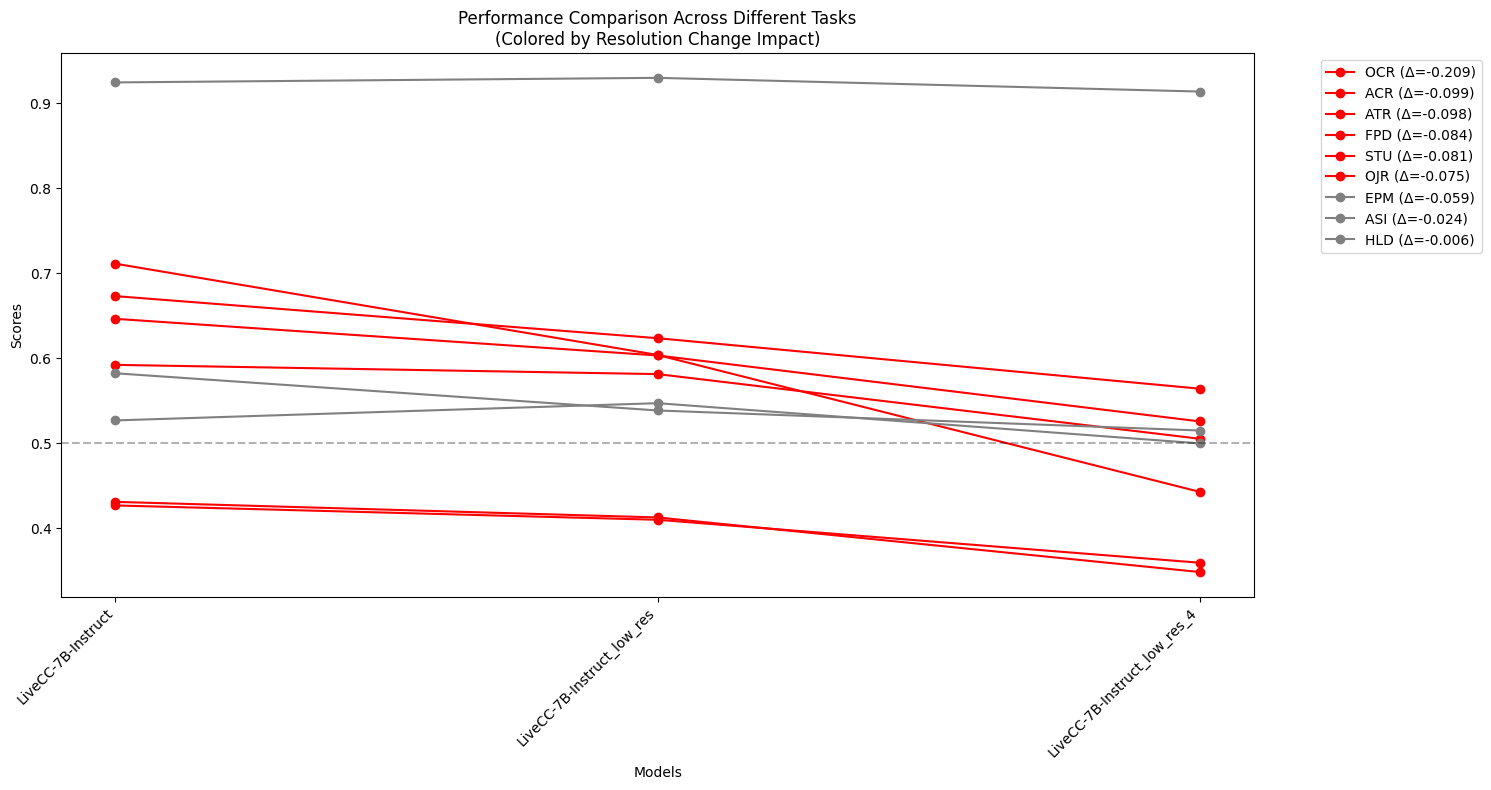

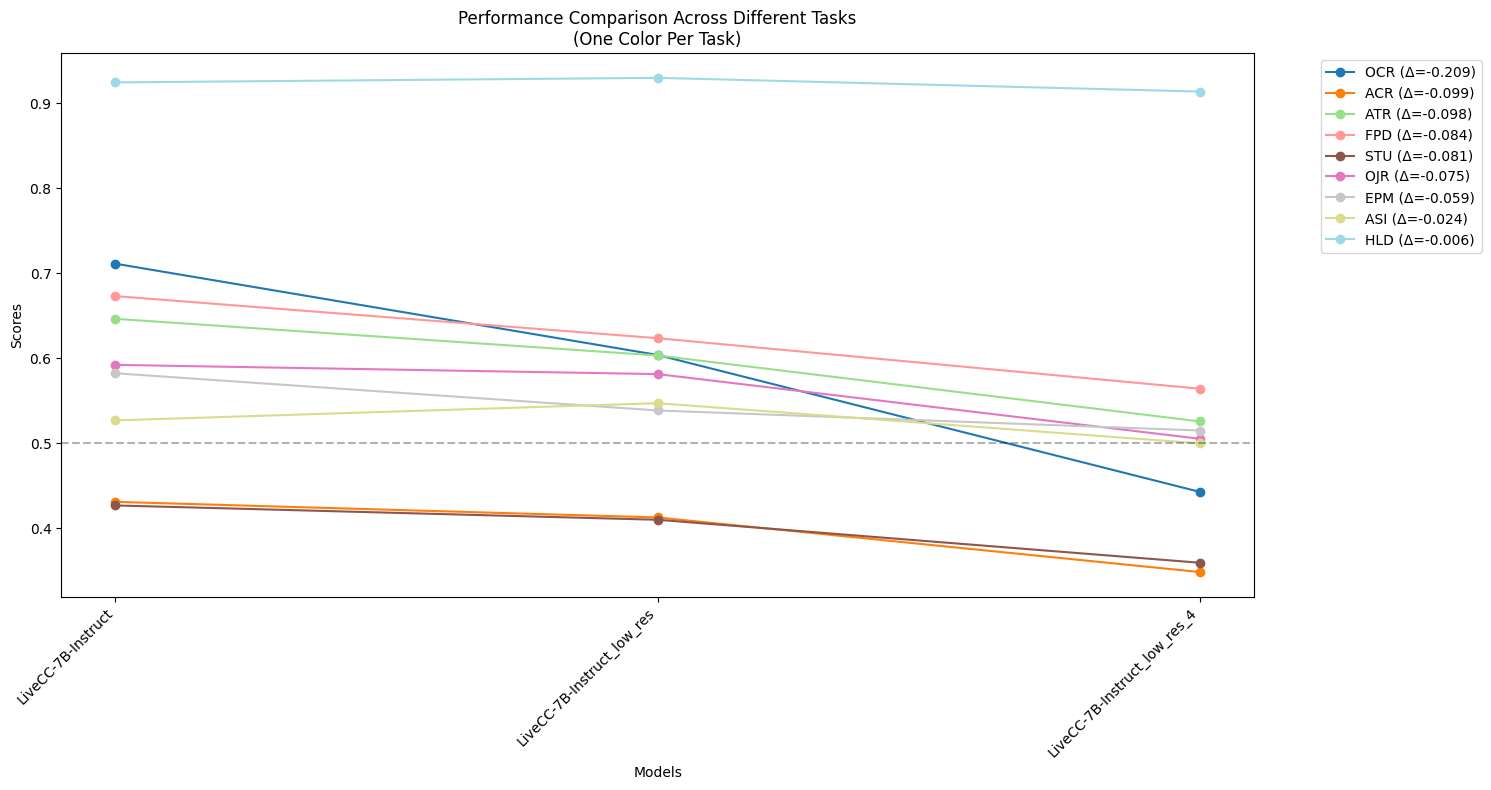

In [13]:
import json, os
import matplotlib.pyplot as plt
import numpy as np

# Define the models and their scores for each task
models = ['LiveCC-7B-Instruct', 'LiveCC-7B-Instruct_low_res', 'LiveCC-7B-Instruct_low_res_4']
tasks = ['EPM', 'HLD', 'ASI', 'STU', 'OJR', 'ATR', 'FPD', 'ACR', 'OCR']

# Scores for each task across models
def parse_score_line(line):
    """Parse a line like 'EPM: 173/297=0.5824915824915825' into task name and score"""
    task, score_str = line.strip().split(': ')
    score = float(score_str.split('=')[1])
    return task, score

def read_scores_from_file(file_path):
    """Read scores from a txt file and return a dictionary of task scores"""
    scores = {}
    with open(file_path, 'r') as f:
        for line in f:
            if '=' in line:  # Only process lines with scores
                task, score = parse_score_line(line)
                scores[task] = score
    return scores

# Read scores from all result files
result_files = [
    'LiveCC-7B-Instruct.txt',
    'LiveCC-7B-Instruct_low_res.txt', 
    'LiveCC-7B-Instruct_low_res_4.txt'
]

all_scores = {}
for file in result_files:
    file_path = f'evaluation/ovobench/results/{file}'
    scores = read_scores_from_file(file_path)
    for task, score in scores.items():
        if task not in all_scores:
            all_scores[task] = []
        all_scores[task].append(score)

# Calculate performance changes between models
def calculate_changes(scores):
    changes = {}
    for task in scores:
        task_scores = scores[task]
        if len(task_scores) >= 2:
            # Calculate change from high to low resolution
            # Calculate average change rate between consecutive scores
            task_changes = []
            for i in range(len(task_scores)-1):
                change_rate = (task_scores[i+1] - task_scores[i]) / task_scores[i]
                task_changes.append(change_rate)
            change = sum(task_changes) / len(task_changes) if task_changes else 0
            changes[task] = change
    return changes

# Calculate changes and sort tasks by magnitude of change
changes = calculate_changes(all_scores)
sorted_tasks = sorted(tasks, key=lambda x: abs(changes.get(x, 0)), reverse=True)

# Create the plot
# First plot - colored by change magnitude
plt.figure(figsize=(15, 8))
x = np.arange(len(models))

# Plot each task as a line, using different colors based on change magnitude
for task in sorted_tasks:
    task_scores = all_scores[task]
    # Filter out None values
    valid_scores = [(i, score) for i, score in enumerate(task_scores) if score is not None]
    if valid_scores:
        x_valid = [x[i] for i, _ in valid_scores]
        y_valid = [score for _, score in valid_scores]
        
        # Color coding based on change magnitude
        change = changes.get(task, 0)
        if abs(change) >= 0.07:  # Significant change
            color = 'red' 
        elif change > 0:
            color = 'blue'
        else:  # Minimal change
            color = 'gray'
            
        plt.plot(x_valid, y_valid, marker='o', label=f'{task} (Δ={change:.3f})', color=color)

plt.xlabel('Models')
plt.ylabel('Scores')
plt.title('Performance Comparison Across Different Tasks\n(Colored by Resolution Change Impact)')
plt.xticks(x, models, rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Add a horizontal line at y=0.5 for reference
plt.axhline(y=0.5, color='black', linestyle='--', alpha=0.3)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show the plot
plt.show()

# Second plot - one color per task
plt.figure(figsize=(15, 8))
x = np.arange(len(models))

# Generate distinct colors for each task
colors = plt.cm.tab20(np.linspace(0, 1, len(sorted_tasks)))

# Plot each task as a line with unique color
for idx, task in enumerate(sorted_tasks):
    task_scores = all_scores[task]
    # Filter out None values
    valid_scores = [(i, score) for i, score in enumerate(task_scores) if score is not None]
    if valid_scores:
        x_valid = [x[i] for i, _ in valid_scores]
        y_valid = [score for _, score in valid_scores]
        
        change = changes.get(task, 0)
        plt.plot(x_valid, y_valid, marker='o', label=f'{task} (Δ={change:.3f})', color=colors[idx])

plt.xlabel('Models')
plt.ylabel('Scores')
plt.title('Performance Comparison Across Different Tasks\n(One Color Per Task)')
plt.xticks(x, models, rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Add a horizontal line at y=0.5 for reference
plt.axhline(y=0.5, color='black', linestyle='--', alpha=0.3)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show the plot
plt.show()


['hirest', 'youcook2', 'AutoEvalMetaData', 'MovieNet', 'Ego4D', 'OpenEQA', 'perception_test', 'thumos', 'star', 'cross_task', 'COIN', 'YouTube_Games']


load datums: 100%|██████████| 3035/3035 [00:00<00:00, 140824.75it/s]

3035 3035
Ego4D/clips/ec4a3ba3-eb00-4aa8-9b41-36043ece98f7.mp4
Ego4D/clips/ec4a3ba3-eb00-4aa8-9b41-36043ece98f7.mp4
Ego4D/clips/ec4a3ba3-eb00-4aa8-9b41-36043ece98f7.mp4
Ego4D/clips/ec4a3ba3-eb00-4aa8-9b41-36043ece98f7.mp4
Ego4D/clips/4ba774a8-cd2a-4889-9971-cc91f5c1afd4.mp4
Ego4D/clips/4ba774a8-cd2a-4889-9971-cc91f5c1afd4.mp4
Ego4D/clips/4ba774a8-cd2a-4889-9971-cc91f5c1afd4.mp4
Ego4D/clips/4ba774a8-cd2a-4889-9971-cc91f5c1afd4.mp4
Ego4D/clips/534d9bf8-bdc5-4236-8dba-dd7b894218d2.mp4
Ego4D/clips/534d9bf8-bdc5-4236-8dba-dd7b894218d2.mp4
Ego4D/clips/534d9bf8-bdc5-4236-8dba-dd7b894218d2.mp4
Ego4D/clips/84aae2af-1a45-4e2a-ac52-eb7aeffe212d.mp4
Ego4D/clips/84aae2af-1a45-4e2a-ac52-eb7aeffe212d.mp4
Ego4D/clips/84aae2af-1a45-4e2a-ac52-eb7aeffe212d.mp4
Ego4D/clips/84aae2af-1a45-4e2a-ac52-eb7aeffe212d.mp4
Ego4D/clips/a40dce18-488d-4acc-b754-fcd56c204db1.mp4
Ego4D/clips/a40dce18-488d-4acc-b754-fcd56c204db1.mp4
Ego4D/clips/a40dce18-488d-4acc-b754-fcd56c204db1.mp4
Ego4D/clips/a40dce18-488d-4acc-b754-

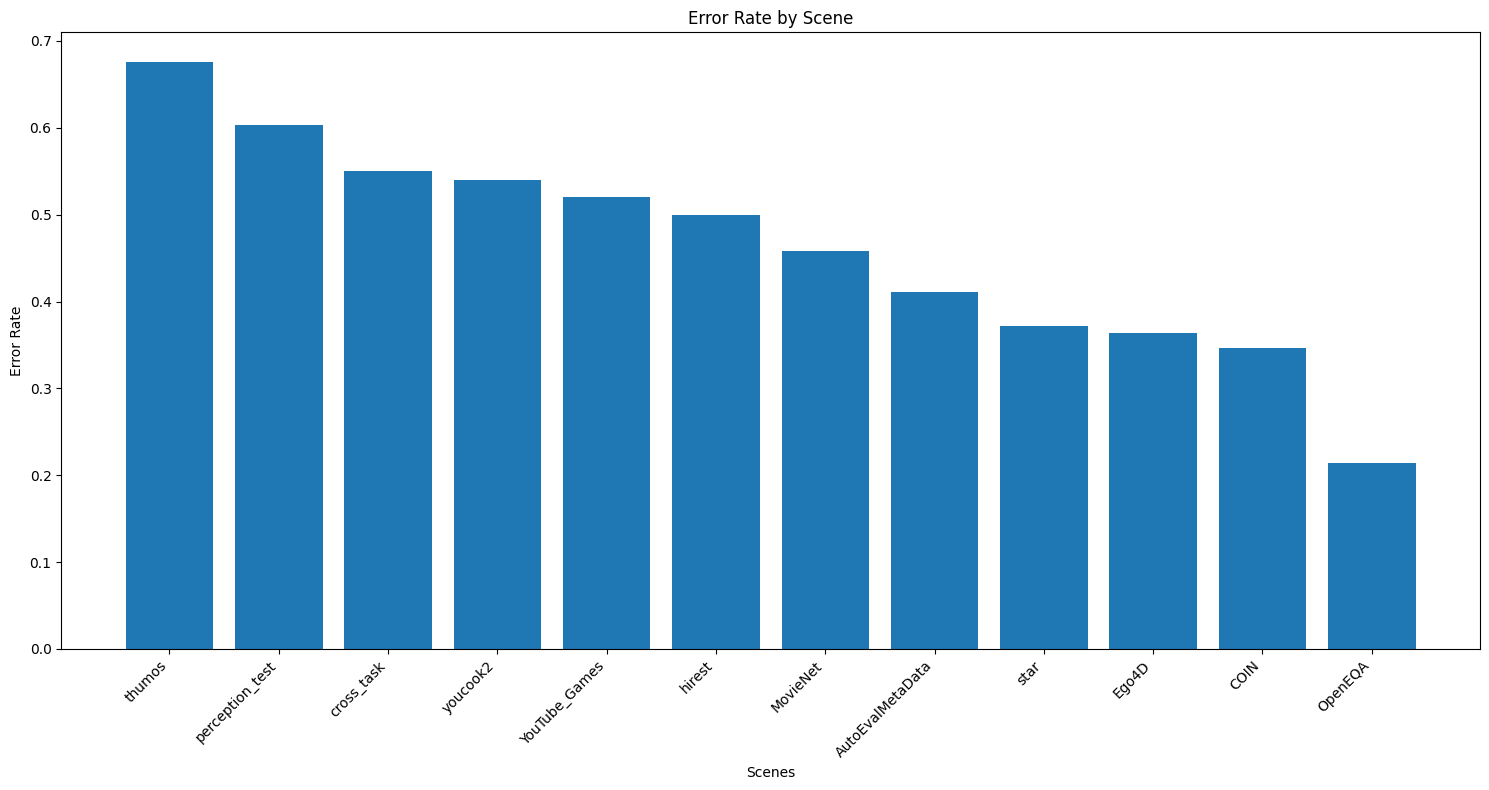


Error rates by scene:
thumos: 0.676 (334/494)
perception_test: 0.603 (123/204)
cross_task: 0.550 (11/20)
youcook2: 0.540 (27/50)
YouTube_Games: 0.521 (50/96)
hirest: 0.500 (10/20)
MovieNet: 0.458 (110/240)
AutoEvalMetaData: 0.411 (217/528)
star: 0.372 (16/43)
Ego4D: 0.363 (190/523)
COIN: 0.346 (223/644)
OpenEQA: 0.214 (37/173)


In [18]:
import json, os, tqdm

scenes  = os.listdir("/2022233235/.cache/huggingface/hub/datasets--JoeLeelyf--OVO-Bench/snapshots/fec29e3385747b5642d995370143ba92d2819bd2/src_videos/")
print(scenes)
scene2error = {}
for scene in scenes:
    scene2error[scene] = 0
scene2total = {}
for scene in scenes:
    scene2total[scene] = 0



lines = open("/2022233235/videollm-online/livecc/ovo-bench-formatted.jsonl").readlines()
dums = [json.loads(line) for line in tqdm.tqdm(lines, desc='load datums')]

results = json.load(open('evaluation/ovobench/results/LiveCC-7B-Instruct.json'))
print(len(dums), len(results))
error_ids = []
for i, result in enumerate(results):
    print(dums[i]['video'])
    scene = dums[i]['video'].split('/')[0]
    scene2total[scene] += 1
    if result['response'][:len(result['answer'])] != result['answer']:
        scene2error[scene] += 1

# Calculate error rates for each scene
scene2error_rate = {}
for scene in scene2error:
    if scene2total[scene] > 0:
        scene2error_rate[scene] = scene2error[scene] / scene2total[scene]
    else:
        scene2error_rate[scene] = 0

# Sort scenes by error rate
sorted_scenes = sorted(scene2error_rate.items(), key=lambda x: x[1], reverse=True)

# Create bar plot
plt.figure(figsize=(15, 8))
scenes = [x[0] for x in sorted_scenes]
error_rates = [x[1] for x in sorted_scenes]

plt.bar(scenes, error_rates)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Scenes')
plt.ylabel('Error Rate')
plt.title('Error Rate by Scene')
plt.tight_layout()
plt.show()

# Print numerical results
print("\nError rates by scene:")
for scene, rate in sorted_scenes:
    print(f"{scene}: {rate:.3f} ({scene2error[scene]}/{scene2total[scene]})")



# test code

In [2]:
import json, os, torch, functools, tqdm, random, sys
import numpy as np
import decord
from torch.utils.data import Dataset
from transformers import Trainer, TrainingArguments, logging, Qwen2VLForConditionalGeneration, AutoProcessor

from livecc_utils import _read_video_decord_plus, _spatial_resize_video
from qwen_vl_utils.vision_process import process_vision_info, smart_nframes, FPS

logger = logging.get_logger(__name__)

def _read_may1fps_video_decord(ele: dict):
    """read video using decord.VideoReader. can handle more cases compared to _read_video_decord.

    Args:
        ele (dict): a dict contains the configuration of video.
        support keys:
            - video: the path of video. support "file://", "http://", "https://" and local path.
            - video_start: the start time of video.
            - video_end: the end time of video.
    Returns:
        torch.Tensor: the video tensor with shape (T, C, H, W).
        sample_fps
        clip_pts if return_pts=True
    """
    video_path = ele["video"]
    if os.path.exists(video_path):
        vr = decord.VideoReader(video_path, num_threads=2)
    elif ele['remote_loader'] is not None:
        vr = decord.VideoReader(ele['remote_loader'](video_path), num_threads=2)
    else:
        raise ValueError(f'video_path {video_path} not found')
    video_start = ele.get('video_start', None)
    video_end = ele.get('video_end', None)
    video_fps = vr.get_avg_fps()
    print(video_fps)
    clip_idxs, clip_pts = None, None
    if video_start is not None or video_end is not None:
        vr.get_frame_timestamp(0)
        video_pts = vr._frame_pts[:,1]
        video_start = video_pts[0] if not video_start else video_start
        video_end = video_pts[-1] if not video_end else video_end
        video_start = min(max(video_pts[0], video_start), video_pts[-1])
        video_end = min(max(video_pts[0], video_end), video_pts[-1])
        video_end = max(video_start + 1, video_end)
        clip_idxs = ((video_start <= video_pts) & (video_pts <= video_end)).nonzero()[0]
        total_frames = len(clip_idxs)
    else:
        total_frames = len(vr)
        print(total_frames)
    total_frames_for_smart_nframes = total_frames
    video_fps_for_smart_nframes = video_fps
    if total_frames < 2:
        total_frames_for_smart_nframes = 2
    if video_fps < FPS: # FPS=2
        total_frames_for_smart_nframes = int(total_frames * FPS / video_fps)
        video_fps_for_smart_nframes = FPS
    nframes = smart_nframes(ele, total_frames=total_frames_for_smart_nframes, video_fps=video_fps_for_smart_nframes) 
    print(FPS, total_frames_for_smart_nframes, nframes, video_fps_for_smart_nframes)
    nframes_idxs = np.linspace(0, total_frames - 1, nframes).round().astype(int)
    clip_idxs = nframes_idxs if clip_idxs is None else clip_idxs[nframes_idxs]
    # clip = torch.from_numpy(vr.get_batch(clip_idxs).asnumpy()).permute(0, 3, 1, 2)  # Convert to TCHW format
    sample_fps = len(clip_idxs) / max(total_frames, 1e-6) * video_fps
    return  sample_fps
src_video_dir = os.path.dirname("/2022233235/.cache/huggingface/hub/datasets--JoeLeelyf--OVO-Bench/snapshots/fec29e3385747b5642d995370143ba92d2819bd2/src_videos/")
_ = _read_may1fps_video_decord({'video': os.path.join(src_video_dir, 'AutoEvalMetaData/42.mp4'),'video_start': 10, 'video_end': 20,'fps': 4, 'remote_loader': None})
 

29.97002997002997
2.0 300 40 29.97002997002997


In [1]:
import json

results = json.load(open("/2022233235/videollm-online/livecc/evaluation/ovobench/results/Qwen2-VL-7B-Instruct.json"))
json.dump(results, open("/2022233235/videollm-online/livecc/evaluation/ovobench/results/Qwen2-VL-7B-Instruct-formatted.json", "w"), indent=4)





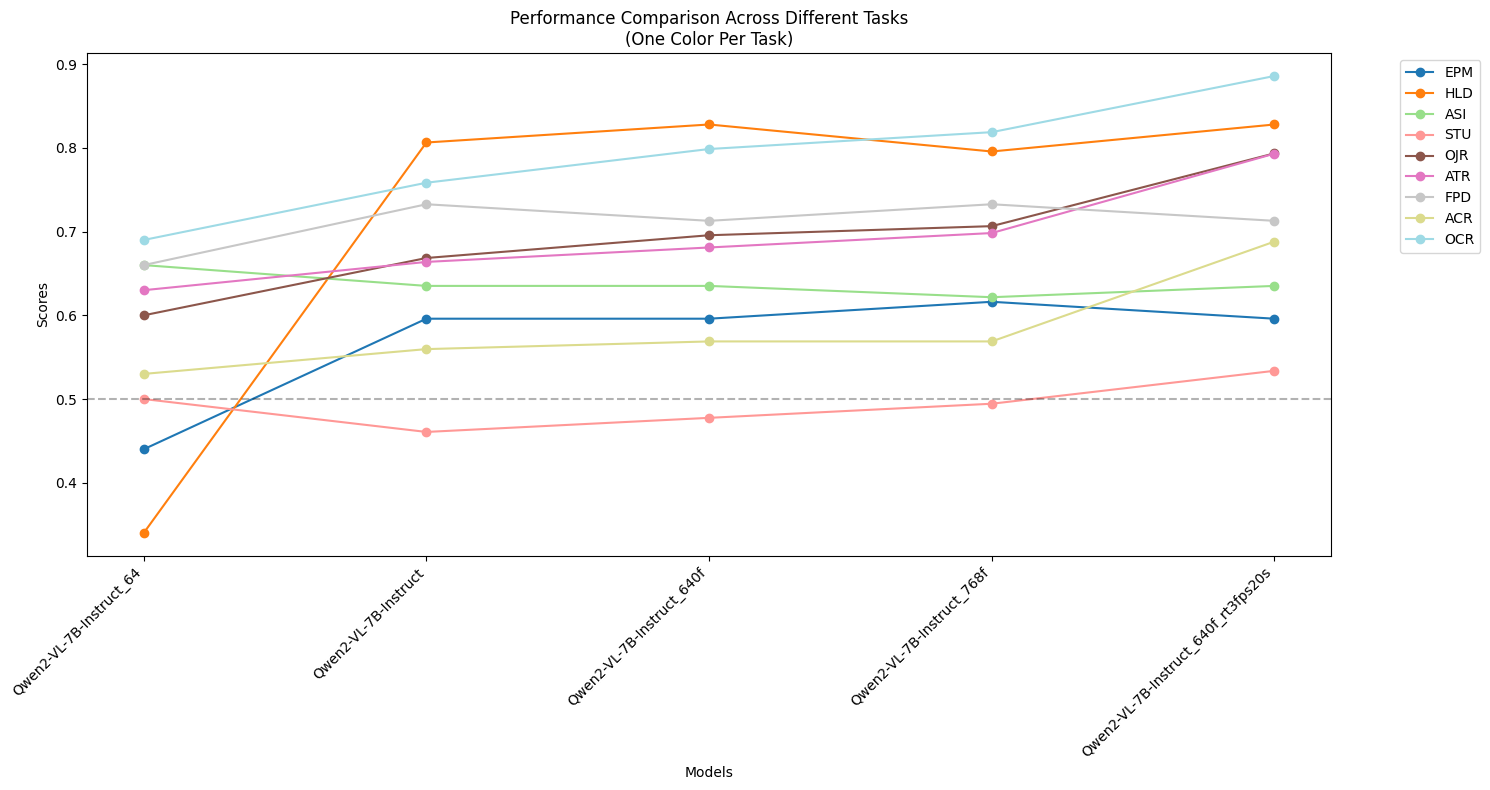

In [5]:
import json, os
import matplotlib.pyplot as plt
import numpy as np

# Define the models and their scores for each task

tasks = ['EPM', 'HLD', 'ASI', 'STU', 'OJR', 'ATR', 'FPD', 'ACR', 'OCR']

# Scores for each task across models
def parse_score_line(line):
    """Parse a line like 'EPM: 173/297=0.5824915824915825' into task name and score"""
    task, score_str = line.strip().split(': ')
    score = float(score_str.split('=')[1])
    return task, score

def read_scores_from_file(file_path):
    """Read scores from a txt file and return a dictionary of task scores"""
    scores = {}
    with open(file_path, 'r') as f:
        for line in f:
            if '=' in line:  # Only process lines with scores
                task, score = parse_score_line(line)
                scores[task] = score
    return scores

# Read scores from all result files
result_files = [
    'Qwen2-VL-7B-Instruct_64.txt',
    'Qwen2-VL-7B-Instruct.txt', 
    'Qwen2-VL-7B-Instruct_640f.txt', 
    'Qwen2-VL-7B-Instruct_768f.txt',
    'Qwen2-VL-7B-Instruct_640f_rt3fps20s.txt'
]

all_scores = {}
for file in result_files:
    file_path = f'evaluation/ovobench/results/{file}'
    scores = read_scores_from_file(file_path)
    for task, score in scores.items():
        if task not in all_scores:
            all_scores[task] = []
        all_scores[task].append(score)
        
models = ['Qwen2-VL-7B-Instruct_64', 'Qwen2-VL-7B-Instruct', 
          'Qwen2-VL-7B-Instruct_640f', 'Qwen2-VL-7B-Instruct_768f',
          'Qwen2-VL-7B-Instruct_640f_rt3fps20s']  

# Second plot - one color per task
plt.figure(figsize=(15, 8))
x = np.arange(len(models))

# Generate distinct colors for each task
sorted_tasks = sorted(tasks, key=lambda x: abs(all_scores.get(x[0], 0)), reverse=True)
colors = plt.cm.tab20(np.linspace(0, 1, len(sorted_tasks)))

# Plot each task as a line with unique color
for idx, task in enumerate(sorted_tasks):
    task_scores = all_scores[task]
    # Filter out None values
    valid_scores = [(i, score) for i, score in enumerate(task_scores) if score is not None]
    if valid_scores:
        x_valid = [x[i] for i, _ in valid_scores]
        y_valid = [score for _, score in valid_scores]
        
        plt.plot(x_valid, y_valid, marker='o', label=f'{task}', color=colors[idx])

plt.xlabel('Models')
plt.ylabel('Scores')
plt.title('Performance Comparison Across Different Tasks\n(One Color Per Task)')
plt.xticks(x, models, rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Add a horizontal line at y=0.5 for reference
plt.axhline(y=0.5, color='black', linestyle='--', alpha=0.3)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show the plot
plt.show()

# vis effciency 

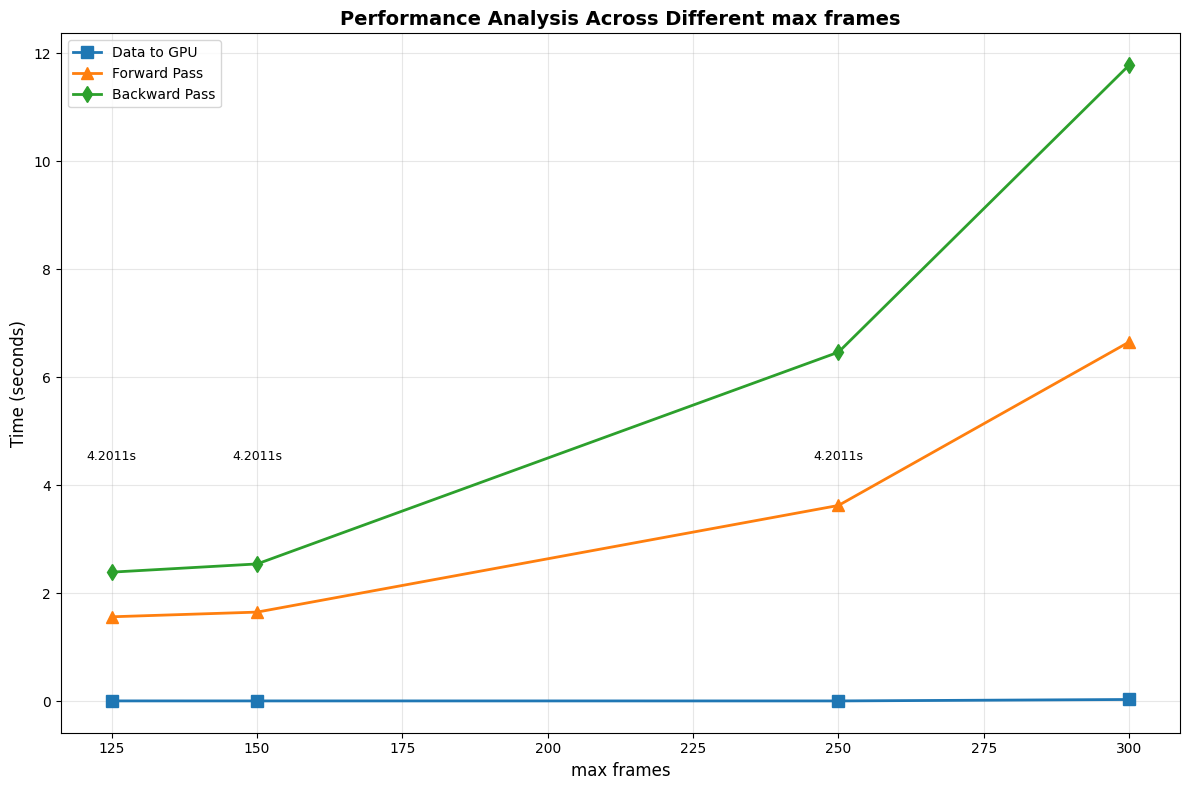

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Data from the performance analysis
data_points = [125, 150, 250, 300]  # x-axis values
data_to_gpu = [0.0074, 0.0071, 0.0069, 0.0335]   # Assuming same value for all points
forward_pass = [1.5646,  1.6512, 3.6256, 6.6512]  # Assuming same value for all points
backward_pass = [2.3910, 2.5429, 6.4632, 11.7765] # Assuming same value for all points

# Create the plot
plt.figure(figsize=(12, 8))

# Plot each metric as a line
plt.plot(data_points, data_to_gpu, marker='s', label='Data to GPU', linewidth=2, markersize=8)
plt.plot(data_points, forward_pass, marker='^', label='Forward Pass', linewidth=2, markersize=8)
plt.plot(data_points, backward_pass, marker='d', label='Backward Pass', linewidth=2, markersize=8)

# Customize the plot
plt.xlabel('max frames', fontsize=12)
plt.ylabel('Time (seconds)', fontsize=12)
plt.title('Performance Analysis Across Different max frames', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# Add value labels on the points
for i, (x, y) in enumerate(zip(data_points, total_step_time)):
    plt.annotate(f'{y:.4f}s', (x, y), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# If you have different values for each data point, you can modify the arrays above
# For example, if you have actual measurements for each point:
# data_loading = [0.3681, 0.3750, 0.3620]  # Different values for 150, 250, 300
# data_to_gpu = [0.0071, 0.0080, 0.0065]   # Different values for 150, 250, 300
# etc.


# vis response density

In [1]:
import json, os

pred_file = "/2022233235/videollm-online/data/estp_dataset/estpSqa_baseline/Qwen2VL_streaming.json"
model = 'Qwen2VL_streaming'

# pred_file = "/2022233235/videollm-online/data/estp_dataset/estp_bench_sq_VideollmOnline0.8.json"
# model = 'VideollmOnline'

# pred_file = "/2022233235/videollm-online/data/estp_dataset/estpSqa_ours/LivebaseStage2_woDino.json"
# model = 'EWO'


parent_dir = os.path.dirname(pred_file)
eval_files = [os.path.join(parent_dir, f) for f in os.listdir(parent_dir) if f.startswith(pred_file.split('/')[-1])]
data = {}
for eval_file in eval_files:
    data.update(json.load(open(eval_file)))
    
for k, v in data.items():
    for kk, vv in v.items():
        for qa in vv:
            if model in qa:
                # Get the model responses
                model_responses = qa[model]
                
                # Extract timestamps from responses
                timestamps = [3]
                for response in model_responses:
                    if response['role'] == 'assistant' and 'time' in response:
                        timestamps.append(response['time'])
                
                # Calculate response frequency in 10 segments
                if timestamps:
                    # Get video start and end times from the question
                    clip_start_time = min(timestamps)
                    clip_end_time = max(timestamps)
                    # Calculate segment duration
                    segment_duration = max(1, (clip_end_time - clip_start_time))
                    
                    if len(timestamps) > 10:
                        segment_duration = segment_duration / 10
                        segment_frequencies = [0] * 10
                    elif len(timestamps) > 5:
                        segment_duration = segment_duration / 5
                        segment_frequencies = [0] * 5
                    else:
                        segment_frequencies = [0] 
                    
                    # Count responses in each segment
                    for timestamp in timestamps:
                        if clip_start_time <= timestamp <= clip_end_time:
                            segment_index = min(int((timestamp - clip_start_time) / segment_duration), len(segment_frequencies) - 1)
                            segment_frequencies[segment_index] += 1
                    
                    for i in range(len(segment_frequencies)):
                        segment_frequencies[i] = segment_frequencies[i] / segment_duration
                    
                    # Store segment frequency information
                    qa[f'{model}_segment_frequency'] = {
                        'clip_start_time': clip_start_time,
                        'clip_end_time': clip_end_time,
                        'segment_duration': segment_duration,
                        'segment_frequencies': segment_frequencies,
                        'total_responses': len(timestamps),
                        'timestamps': timestamps
                    }
        
    

    

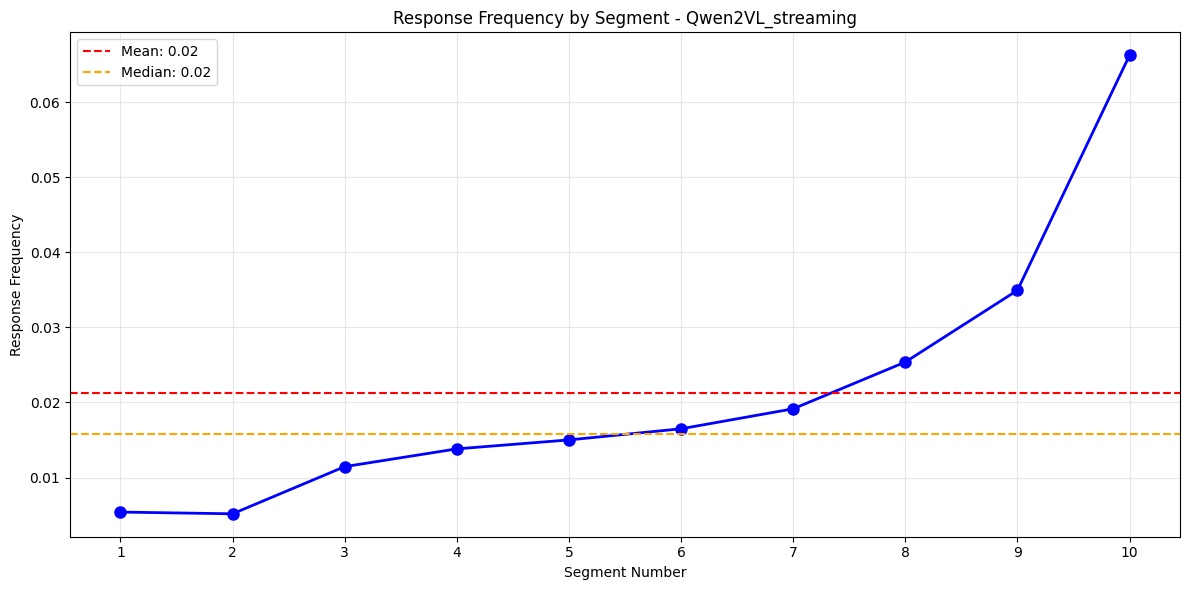

Total segments analyzed: 10
Mean response frequency: 0.02
Median response frequency: 0.02
Max response frequency: 0.06624656187136531
Min response frequency: 0.005170521245849687


In [2]:
# 绘制响应密度图，横坐标为10个时间段
import matplotlib.pyplot as plt
import numpy as np

# 收集所有模型的segment_frequencies数据
all_segment_frequencies = [0] * 10
count = 0

for k, v in data.items():
    for kk, vv in v.items():
        for qa in vv:
            if model in qa and f'{model}_segment_frequency' in qa:
                
                
                segment_frequencies = qa[f'{model}_segment_frequency']['segment_frequencies']
                if len(segment_frequencies) == 10:
                    for i in range(len(segment_frequencies)):
                        all_segment_frequencies[i] += segment_frequencies[i]
                        count += 1
                elif len(segment_frequencies) == 5:
                    # For 5-segment case, duplicate each frequency to fill 10 segments
                    for i in range(len(segment_frequencies)):
                        all_segment_frequencies[i*2] += segment_frequencies[i]
                        all_segment_frequencies[i*2+1] += segment_frequencies[i]
                        count += 1
                    
# norm
# Normalize frequencies by dividing by the total count
if count > 0:
    all_segment_frequencies = [freq / count for freq in all_segment_frequencies]


# 创建密度图
plt.figure(figsize=(12, 6))
plt.plot(range(1, 11), all_segment_frequencies, marker='o', linewidth=2, markersize=8, color='blue')
plt.xlabel('Segment Number')
plt.ylabel('Response Frequency')
plt.title(f'Response Frequency by Segment - {model}')
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 11))

# 添加统计信息
mean_freq = np.mean(all_segment_frequencies)
median_freq = np.median(all_segment_frequencies)
plt.axhline(mean_freq, color='red', linestyle='--', label=f'Mean: {mean_freq:.2f}')
plt.axhline(median_freq, color='orange', linestyle='--', label=f'Median: {median_freq:.2f}')
plt.legend()

plt.tight_layout()
plt.show()

# 打印统计信息
print(f"Total segments analyzed: {len(all_segment_frequencies)}")
print(f"Mean response frequency: {mean_freq:.2f}")
print(f"Median response frequency: {median_freq:.2f}")
print(f"Max response frequency: {max(all_segment_frequencies)}")
print(f"Min response frequency: {min(all_segment_frequencies)}")


# egoit

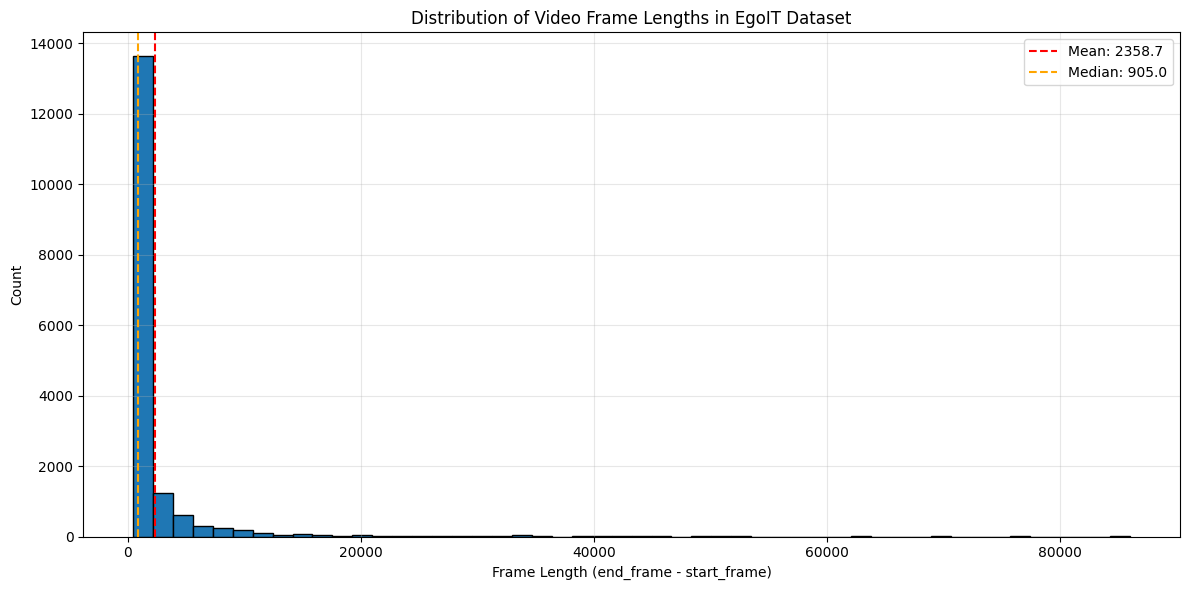

Total video samples with frame info: 16750
Mean frame length: 2358.7
Median frame length: 905.0
Max frame length: 86014
Min frame length: 449


In [8]:
# Load and analyze EgoIT dataset

import json
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
with open('/2024233235/.cache/huggingface/hub/datasets--lmms-lab--EgoIT-99K/snapshots/a57f1f2078a7b01ea87014050fdb3afe169e54f1/datasets/EgoIT_process.json', 'r') as f:
    data = json.load(f)

# Calculate frame length distribution
frame_lengths = []
for item in data:
    if 'video' in item and 'start_frame' in item and 'end_frame' in item:
        frame_length = item['end_frame'] - item['start_frame']
        if frame_length > 7 * 64:
            frame_lengths.append(frame_length)

# Plot histogram
plt.figure(figsize=(12, 6))
plt.hist(frame_lengths, bins=50, edgecolor='black')
plt.xlabel('Frame Length (end_frame - start_frame)')
plt.ylabel('Count')
plt.title('Distribution of Video Frame Lengths in EgoIT Dataset')
plt.grid(True, alpha=0.3)

# Add statistics
mean_length = np.mean(frame_lengths)
median_length = np.median(frame_lengths)
plt.axvline(mean_length, color='red', linestyle='--', label=f'Mean: {mean_length:.1f}')
plt.axvline(median_length, color='orange', linestyle='--', label=f'Median: {median_length:.1f}')
plt.legend()

plt.tight_layout()
plt.show()

# Print statistics
print(f"Total video samples with frame info: {len(frame_lengths)}")
print(f"Mean frame length: {mean_length:.1f}")
print(f"Median frame length: {median_length:.1f}")
print(f"Max frame length: {max(frame_lengths)}")
print(f"Min frame length: {min(frame_lengths)}")


# ETBENCH

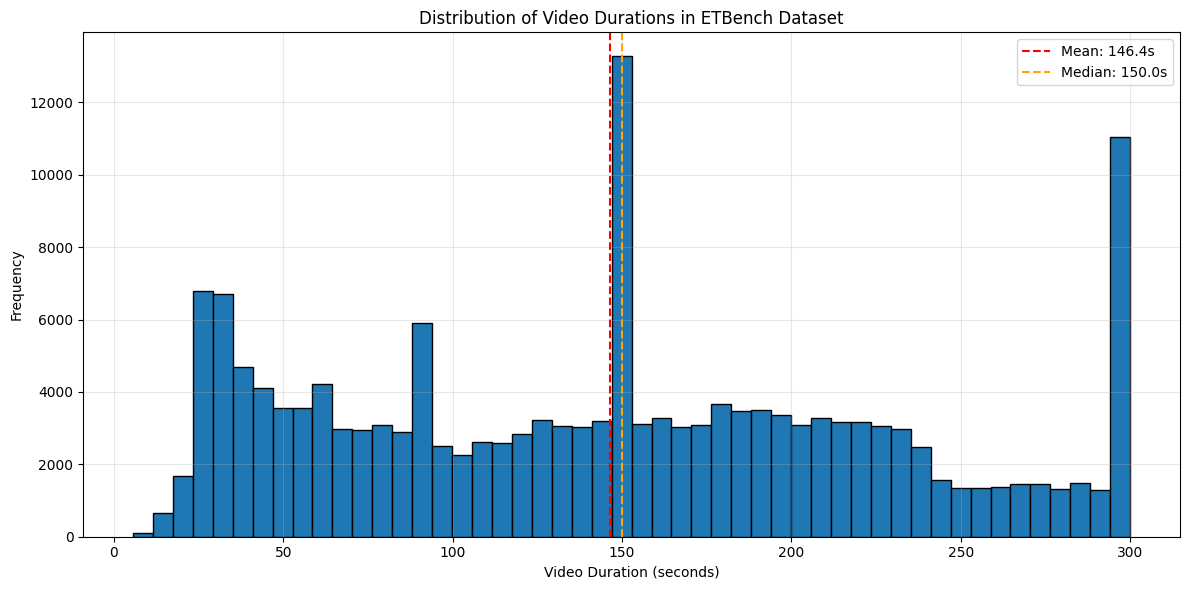

Total videos: 163880
Mean duration: 146.4s
Median duration: 150.0s
Max duration: 300.0s
Min duration: 5.7s


In [3]:
import json
import matplotlib.pyplot as plt
import numpy as np
# Load and analyze video durations from ETBench dataset
with open('/2024233235/videollm-online/EyeWO2/data/etbench_qwen2vl_video_info.json', 'r') as f:
    video_info = json.load(f)

# Extract durations
durations = []
for duration in video_info:

        durations.append(duration)

# Plot histogram
plt.figure(figsize=(12, 6))
plt.hist(durations, bins=50, edgecolor='black')
plt.xlabel('Video Duration (seconds)')
plt.ylabel('Frequency')
plt.title('Distribution of Video Durations in ETBench Dataset')
plt.grid(True, alpha=0.3)

# Add statistics
mean_duration = np.mean(durations)
median_duration = np.median(durations)
plt.axvline(mean_duration, color='red', linestyle='--', label=f'Mean: {mean_duration:.1f}s')
plt.axvline(median_duration, color='orange', linestyle='--', label=f'Median: {median_duration:.1f}s')
plt.legend()

plt.tight_layout()
plt.show()

# Print statistics
print(f"Total videos: {len(durations)}")
print(f"Mean duration: {mean_duration:.1f}s")
print(f"Median duration: {median_duration:.1f}s")
print(f"Max duration: {max(durations):.1f}s")
print(f"Min duration: {min(durations):.1f}s")